# Try to use pytorch on the PPMI data

First import libs and define paths

In [1]:
import pandas as pd
import os

In [2]:

base_path = "/home/data/PPMI"
participants_file = os.path.join(base_path, "rawdata/participants.tsv")
curated_file = os.path.join(base_path, "documents/PPMI_Curated_Data_Cut_Public_20240729.xlsx")

In [3]:
# ----------------------- mirar tsv
print("Info on participants.tsv")
try:
    df_p = pd.read_csv(participants_file, sep='\t')
    print("Total subjects: ", len(df_p))

    # Look for a 'diagnosis' or 'group' column
    if 'diagnosis' in df_p.columns:
        print(df_p['diagnosis'].value_counts())
    else:
        print("Columns available:", df_p.columns.tolist())
except Exception as e:
    print("Could not read participants.tsv: ", e)

Info on participants.tsv
Total subjects:  955
Columns available: ['participant_id', 'cohort', 'sex', 'birth_date', 'education', 'handed']


In [6]:
# ----------------------- mirar excel
print("Info on the excel")
try:
    df_c = pd.read_excel(curated_file)
    print(f"Total entries in curated data: {len(df_c)}")

    # Common PPMI diagnosis labels: PD (Parkinson's), HC (Healthy Control), SWEDD
    if 'COHORT_DEFINITION' in df_c.columns:
        print(df_c['COHORT_DEFINITION'].value_counts())
    else:
        # If the column name is different lemme see them
        print("Columns available:", df_c.columns.tolist()[:10], "...(truncated)")

except Exception as e:
    print(f"Could not read Excel file: {e}")

Info on the excel
Total entries in curated data: 13242
Columns available: ['SITE', 'PATNO', 'COHORT', 'subgroup', 'enroll_phase', 'HIQ_RBD', 'study_status', 'NSD_Status', 'NSD_STAGE', 'PRIMDIAG'] ...(truncated)


# Pytorch

If all above works, load `pytorch` and `nibabel`.

In [4]:
import torch
from torch.utils.data import Dataset
import nibabel as nib
import numpy as np

pytorch needs a dataset class to handle the "fetching" of stuff like which patient is and is not sick.

In [5]:
class PPMIDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load the 3D NIfTI file
        img = nib.load(self.file_paths[idx]).get_fdata()

        # Preprocessing
        img = (img - np.mean(img)) / np.std(img) # Normalize intensity

        # Convert to Torch Tensor (Add a 'channel' dimension for the CNN)
        # Shape becomes: [1, Depth, Height, Width]
        img_tensor = torch.from_numpy(img).float().unsqueeze(0)

        label = torch.tensor(self.labels[idx])
        return img_tensor, label

In [6]:
import glob

In [7]:
derivatives_path = os.path.join(base_path, "derivatives/dat-reg-v6")
excel_path = os.path.join(base_path, "documents/PPMI_Curated_Data_Cut_Public_20240729.xlsx")

# Load the labels
df = pd.read_excel(excel_path)

# agafam només el num del pacient i el seu cohort
labels_map = df[['PATNO', 'COHORT']].drop_duplicates().set_index('PATNO')['COHORT'].to_dict()
#print("labels map: ", labels_map)

# trobam totes les "ses-BL" de DaTscan
baseline_images = glob.glob(f"{derivatives_path}/sub-*/ses-BL/spect/*_DaTSCAN.nii.gz") # màgia negra
#print("baseline_images: ", baseline_images)

data_list = []

for img_path in baseline_images:

    # agafam PATNO com a int del filename (aka sub-PPMI100001 -> 100001)
    sub_id = img_path.split('/')[-4] # només 'sub-PPMI100001'
    patno = int(sub_id.replace('sub-PPMI', ''))

    # haurien d ser iguals
    #print("img_path:\t", img_path)
    #print("patno:\t", patno)

    # agafam el cohort si el pacient tenia metadades al excel
    # segur q pandas té algo més ràpid x fer això
    if patno in labels_map:
        cohort = labels_map[patno]
        # x ara només interessen els PD i healthy
        if cohort in [1, 2]: #  cohort 1 són els PD i cohort 2 són els healthy
            label = 1 if cohort == 1 else 0 # els PD es marquen com 1 i els healthy es posen a 0
            #data_list.append({'path': img_path, 'label': label, 'cohort': cohort})
            data_list.append({'path': img_path, 'label': label})

# Create a final clean CSV for training
clean_df = pd.DataFrame(data_list)
print("clean_df:")
print(clean_df.head(10))
print(clean_df['label'].value_counts())

clean_df:
                                                path  label
0  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
1  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
2  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
3  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      0
4  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
5  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
6  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
7  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
8  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      1
9  /home/data/PPMI/derivatives/dat-reg-v6/sub-PPM...      0
label
1    561
0    124
Name: count, dtype: int64


In [8]:
# save the mapping to a file
clean_df.to_csv("ppmi_baseline_mapping.csv", index=False)
print("\nMapping saved to 'ppmi_baseline_mapping.csv'!")


Mapping saved to 'ppmi_baseline_mapping.csv'!


Now we have a cleaned-up dataset with only PD or not.

# Train-test split

Now scikit learn comes in to train-split the dataset

In [9]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("ppmi_baseline_mapping.csv")
# 80% Train, 20% Test/Validation for now?
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=69)

print(f"Original df: {len(df)} samples")
print(f"Training on: {len(train_df)} samples")
print(f"Testing on: {len(test_df)} samples")

Original df: 685 samples
Training on: 548 samples
Testing on: 137 samples


# CNN

And once that's done, onto creating the CNN


## Arreglar `pytorch`/cuda:

Per algun motiu, cada pic em demana que em reinstali cuda amb la versió 12.6 tot i haver-ho fet. Desinstalar i reinstalar ho soluciona. Tarda ~1 min.
```sh
pip3 uninstall torch torchvision
pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126
```

In [ ]:
#!pip3 uninstall torch torchvision -y
#!pip3 install torch torchvision
#!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu124

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp310-cp310-linux_x86_64.whl (768.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp310-cp310-linux_x86_64.whl (7.3 MB)


Pareix q tot i així no li omple xq falta una Kernel Image. La documentació no diu com solucionar.



In [10]:
import torch
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"Compute Capability: {torch.cuda.get_device_capability(0)}")
print(f"PyTorch CUDA version: {torch.version.cuda}")

GPU Name: NVIDIA GeForce GTX 1080 Ti
Compute Capability: (6, 1)
PyTorch CUDA version: 12.4


In [11]:
import torch
x = torch.rand(5, 3)
print(x)

tensor([[0.8700, 0.8548, 0.2071],
        [0.0844, 0.2972, 0.9769],
        [0.3426, 0.5283, 0.1308],
        [0.1312, 0.5624, 0.1388],
        [0.0803, 0.4927, 0.5020]])


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ParkinsonClassifier3D(nn.Module):
    def __init__(self):
        super(ParkinsonClassifier3D, self).__init__()
        # Input: 1 channel (scan), Output: 16 filters
        self.conv1 = nn.Conv3d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool3d(2)

        self.conv2 = nn.Conv3d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv3d(32, 64, kernel_size=3, padding=1)

        # This part depends on image dimensions (91x109x91, isnt it?)
        # Global Average Pooling to avoid calculating flat dimensions
        self.gap = nn.AdaptiveAvgPool3d(1)

        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1) # Binary output (0 or 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.gap(x) # Flattens to [Batch, 64, 1, 1, 1]
        x = x.view(-1, 64) # Flattens to [Batch, 64]

        x = F.relu(self.fc1(x))
        # sigmoid for binary classification probability bcs why not
        x = torch.sigmoid(self.fc2(x))
        return x

model = ParkinsonClassifier3D().to("cuda") # Send to GPU

## Loading the images

Nibabel is handy here since it takes the .nii.gz files and loads them to images.

In [13]:
import nibabel as nib
from torch.utils.data import Dataset, DataLoader

This is just a quik test to see if nibabel is properly set and if the images are being loaded adequately.

In [14]:
######################### testing nibabel
for i in range(2):
    print(f"Training image {i+1}")

    ist_path = train_df.iloc[i]['path']
    ist_label = train_df.iloc[i]['label']

    #print("path : ", ist_path)
    print("label: ", ist_label)

    ist_img = nib.load(ist_path)
    ist_img_data = ist_img.get_fdata()

    if ist_img_data.dtype != np.dtype(np.float64):
        print("ist_img_data is not float64")

    # Normalize
    ist_img_data = (ist_img_data - ist_img_data.mean()) / (ist_img_data.std() + 1e-8)

    # Convert to tensor and add channel dim: [1, D, H, W]
    img_tensor = torch.from_numpy(ist_img_data).float().unsqueeze(0)
    label_tensor = torch.tensor(ist_label).float().unsqueeze(0)

    print("img_tensor shape: ", img_tensor.shape)
    print("label: ", label_tensor)


Training image 1
label:  0
img_tensor shape:  torch.Size([1, 176, 240, 256])
label:  tensor([0.])
Training image 2
label:  1
img_tensor shape:  torch.Size([1, 192, 256, 256])
label:  tensor([1.])


In [15]:
from monai.transforms import (
    Compose,
    LoadImaged,
    Resized,
    ScaleIntensityd,
    EnsureChannelFirstd,
    CenterSpatialCropd
)
from monai.data import Dataset as MonaiDataset

# Define the "Recipe" for your images
# We target a smaller size like 96x96x96 to save GPU memory
data_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    # Option 1: Resize (Squashes the image to fit 96x96x96)
    Resized(keys=["image"], spatial_size=(96, 96, 96)),
    # Option 2: CenterCrop (Trims the edges to fit 96x96x96)
    # seems to center around the commas but idk if this is adding noise
    # (different positionings, cropping varies, even scaling seems to be different too)
    #CenterSpatialCropd(keys=["image"], roi_size=(96, 96, 96)),
    ScaleIntensityd(keys=["image"]),
])

# Re-wrap your data
train_files = [{"image": p, "label": l} for p, l in zip(train_df['path'], train_df['label'])]
train_ds = MonaiDataset(data=train_files, transform=data_transforms)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)

test_files = [{"image": p, "label": l} for p, l in zip(test_df['path'], test_df['label'])]
test_ds = MonaiDataset(data=test_files, transform=data_transforms)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=True)

Once the images are all the same size, the datscandataset can be created (using nibabel to convert the nii.gz files into pytorch tensors just like before but now with the right image dimensions). INCORRECT

Image shape: torch.Size([96, 96, 96]), Label: 1


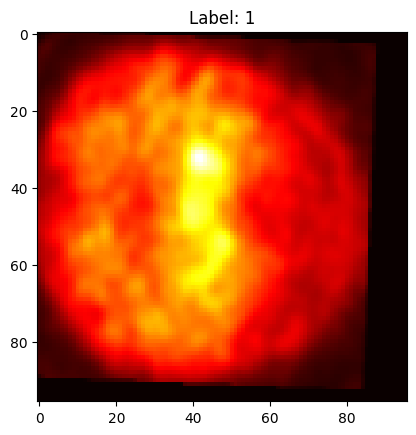

In [16]:
import matplotlib.pyplot as plt

# Grab one batch
check_data = next(iter(train_loader))
image, label = check_data["image"][0][0], check_data["label"][0]

print(f"Image shape: {image.shape}, Label: {label}")

# Plot the middle slice
plt.imshow(image[:, :, 48].cpu(), cmap="hot")
plt.title(f"Label: {label.item()}")
plt.show()

This was to see if Monai had destroyed my images but idk what I'm looking at. Different images look very different. I'm not sure if this is desired behavior. At least they seem to all be the same size. Rotation seems to be varying too.

In [17]:
import torch
# Create a dummy 3D tensor and send it to the GPU
dummy_data = torch.randn(1, 1, 32, 32, 32).to("cuda")
# Run a simple convolution to test the kernel
conv = torch.nn.Conv3d(1, 4, 3).to("cuda")
output = conv(dummy_data)

Ok finaly: now we trainin

In [ ]:
#import torch.optim as optim
#
## Initialize Model, Loss, and Optimizer
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model = ParkinsonClassifier3D().to(device)
#
## Use BCEWithLogitsLoss because it is more numerically stable than putting a Sigmoid inside the model.
## NOTE: If you use this, REMOVE the 'torch.sigmoid' from your model's forward function!
#criterion = nn.BCEWithLogitsLoss()
#optimizer = optim.Adam(model.parameters(), lr=0.0001)
#
## We Trainin
#num_epochs = 10
#
#print(f"Starting training on {device}...")
#
#for epoch in range(num_epochs):
#    model.train() # Set model to training mode
#    running_loss = 0.0
#
#    for i, batch in enumerate(train_loader):
#        # Grabbing tensors from the dictionary by their keys
#        images = batch["image"].to(device)
#        labels = batch["label"].to(device)
#
#        # In MONAI, labels might not have a channel dim yet,
#        # let's ensure it matches the output shape [Batch, 1]
#        if labels.dim() == 1:
#            labels = labels.unsqueeze(1).float()
#
#        optimizer.zero_grad()
#        outputs = model(images)
#        loss = criterion(outputs, labels)
#        loss.backward()
#        optimizer.step()
#
#        running_loss += loss.item()
#
#        if (i + 1) % 5 == 0: # x veure com va
#            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
#
#    print(f"Epoch {epoch+1} average loss: {running_loss/len(train_loader):.4f}")
#
#print("Training Complete!")

Starting training on cuda...
Epoch [1/10], Step [5/274], Loss: 0.7235
Epoch [1/10], Step [10/274], Loss: 0.4754
Epoch [1/10], Step [15/274], Loss: 0.4749
Epoch [1/10], Step [20/274], Loss: 0.7241
Epoch [1/10], Step [25/274], Loss: 0.4729
Epoch [1/10], Step [30/274], Loss: 0.4711
Epoch [1/10], Step [35/274], Loss: 0.4683
Epoch [1/10], Step [40/274], Loss: 0.7270
Epoch [1/10], Step [45/274], Loss: 0.4601
Epoch [1/10], Step [50/274], Loss: 0.7293
Epoch [1/10], Step [55/274], Loss: 0.4495
Epoch [1/10], Step [60/274], Loss: 0.4410
Epoch [1/10], Step [65/274], Loss: 0.4296
Epoch [1/10], Step [70/274], Loss: 0.7407
Epoch [1/10], Step [75/274], Loss: 0.4118
Epoch [1/10], Step [80/274], Loss: 0.3924
Epoch [1/10], Step [85/274], Loss: 0.3811
Epoch [1/10], Step [90/274], Loss: 0.3597
Epoch [1/10], Step [95/274], Loss: 0.7635
Epoch [1/10], Step [100/274], Loss: 0.3605
Epoch [1/10], Step [105/274], Loss: 0.3581
Epoch [1/10], Step [110/274], Loss: 0.3522
Epoch [1/10], Step [115/274], Loss: 0.3473
Ep

KeyboardInterrupt: 

In [ ]:
import os

# Folder to save models in case sth good comes out
os.makedirs("checkpoints", exist_ok=True)

import torch.optim as optim

# Initialize Model, Loss, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ParkinsonClassifier3D().to(device)

# Use BCEWithLogitsLoss because it is more numerically stable than putting a Sigmoid inside the model.
# NOTE: If you use this, REMOVE the 'torch.sigmoid' from your model's forward function
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# We Trainin
num_epochs = 10

print(f"Starting training on {device}...")

best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train() 
    train_running_loss = 0.0
    
    for i, batch in enumerate(train_loader):
        images = batch["image"].to(device)
        labels = batch["label"].float().to(device).view(-1, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()

        if (i + 1) % 50 == 0: # x veure com va
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    avg_train_loss = train_running_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval() 
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # No gradients needed, saves VRAM
        for batch in test_loader:
            images = batch["image"].to(device)
            labels = batch["label"].float().to(device).view(-1, 1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            # Calculate Accuracy
            # Since we use BCEWithLogitsLoss, we need to apply sigmoid
            # or just check if output > 0 (logit 0 = probability 0.5)
            preds = (outputs > 0).float() 
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_running_loss / len(test_loader)
    val_acc = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # --- SAVING THE BEST MODEL ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "checkpoints/best_model.pth")
        print("--> Experimental 'best' model saved!")

    # Save a regular checkpoint every epoch
    torch.save(model.state_dict(), "checkpoints/latest_model.pth")
    print("-" * 30)

Starting training on cuda...


KeyboardInterrupt: 

He exportat el script a un .py i l'he deixat executant al server un rato, ara el model està guardat a `checkpoints/best_model.pth"

In [ ]:
# Re-instantiate the model architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ParkinsonClassifier3D().to(device)

# Load the saved weights
model.load_state_dict(torch.load("checkpoints/best_model.pth"))

# Set to evaluation mode
model.eval()
print("Model loaded yea")

Model loaded and ready for testing!


# Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        images = batch["image"].to(device)
        labels = batch["label"].to(device).view(-1, 1)
        
        outputs = model(images)
        
        # Get probabilities (0 to 1)
        probs = torch.sigmoid(outputs) # If you removed sigmoid from the model class
        
        # Get hard predictions (0 or 1)
        preds = (outputs > 0).float() # to float bcs pytorch is picky and floats are floats

        print(f"image {i}\nprobs:\t{probs}\npreds:\t{preds}")
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to clean numpy arrays
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

image 0
probs:	tensor([[0.7196],
        [0.6770]], device='cuda:0')
preds:	tensor([[1.],
        [1.]], device='cuda:0')
image 1
probs:	tensor([[0.7309],
        [0.7022]], device='cuda:0')
preds:	tensor([[1.],
        [1.]], device='cuda:0')
image 2
probs:	tensor([[0.7294],
        [0.7220]], device='cuda:0')
preds:	tensor([[1.],
        [1.]], device='cuda:0')
image 3
probs:	tensor([[0.7304],
        [0.7195]], device='cuda:0')
preds:	tensor([[1.],
        [1.]], device='cuda:0')
image 4
probs:	tensor([[0.7182],
        [0.6903]], device='cuda:0')
preds:	tensor([[1.],
        [1.]], device='cuda:0')
image 5
probs:	tensor([[0.6916],
        [0.7272]], device='cuda:0')
preds:	tensor([[1.],
        [1.]], device='cuda:0')
image 6
probs:	tensor([[0.7274],
        [0.7214]], device='cuda:0')
preds:	tensor([[1.],
        [1.]], device='cuda:0')
image 7
probs:	tensor([[0.7227],
        [0.7307]], device='cuda:0')
preds:	tensor([[1.],
        [1.]], device='cuda:0')
image 8
probs:	tensor([[

In [21]:
# Calculate the Matrix
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()

print(f"TP: {tp}\tPD detected")
print(f"TN: {tn}\tHealthy detected")
print(f"FP: {fp}\tHealthy missdiagnosed")
print(f"FN: {fn}\tPD missed")

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print("\nFull Report:")
print(classification_report(all_labels, all_preds, target_names=['Healthy', 'PD']))

TP: 112	PD detected
TN: 0	Healthy detected
FP: 25	Healthy missdiagnosed
FN: 0	PD missed
Sensitivity (Recall): 1.0000
Specificity: 0.0000

Full Report:
              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00        25
          PD       0.82      1.00      0.90       112

    accuracy                           0.82       137
   macro avg       0.41      0.50      0.45       137
weighted avg       0.67      0.82      0.74       137



/home/akarel/src_tfg/pt_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/akarel/src_tfg/pt_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/akarel/src_tfg/pt_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

# results
It looks like the model only learned to say yes. This is bcs the dataset is quite skewed. Let's do sth about it and retrain.

First I'll try rebalancing, get the same ammount of PD and healthy.

In [28]:
# Separate the classes
pd_df = df[df['label'] == 1]
hc_df = df[df['label'] == 0]

pd_df_balanced = pd_df.sample(n=len(hc_df), random_state=42)
balanced_df = pd.concat([pd_df_balanced, hc_df])
# new split
train_df, test_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df['label'], random_state=42)

I'll fix this in the .py version of this so I can retrain headless on the server.